# Heart Disease Prediction

## 3. Feature Selection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("heart_cleaned.csv")

X = df.drop(columns=["num"])
y = (df["num"] > 0).astype(int)

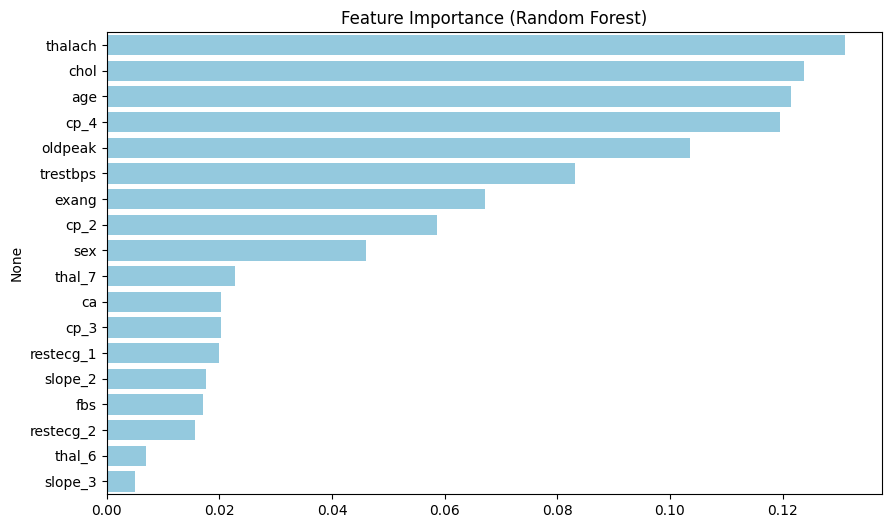

In [3]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices], color="skyblue")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [4]:
log_reg = LogisticRegression(max_iter=1000, solver="liblinear")
rfe = RFE(log_reg, n_features_to_select=8)  # choose top 8 features
rfe.fit(X, y)

selected_rfe = X.columns[rfe.support_]
print("Selected Features by RFE:", list(selected_rfe))


Selected Features by RFE: ['sex', 'exang', 'ca', 'cp_2', 'cp_4', 'restecg_1', 'thal_6', 'thal_7']


In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi2_selector = SelectKBest(score_func=chi2, k=8)
chi2_selector.fit(X_scaled, y)

selected_chi2 = X.columns[chi2_selector.get_support()]
print("Selected Features by Chi2:", list(selected_chi2))

Selected Features by Chi2: ['sex', 'exang', 'ca', 'cp_2', 'cp_3', 'cp_4', 'slope_3', 'thal_7']


In [6]:
final_features = list(set(selected_rfe) | set(selected_chi2) | set(X.columns[indices[:8]]))
print("Final Selected Features:", final_features)

X_reduced = X[final_features]

reduced_df = pd.concat([X_reduced, y], axis=1)
reduced_df.to_csv("reduced_heart_disease.csv", index=False)

Final Selected Features: ['restecg_1', 'chol', 'thal_7', 'ca', 'trestbps', 'cp_3', 'slope_3', 'cp_4', 'age', 'thal_6', 'sex', 'cp_2', 'exang', 'thalach', 'oldpeak']
